# 1. Setup & Environment
- 시계열 공간 데이터 및 지도 제작 라이브러리(GeoPandas, MapClassify, Matplotlib) 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 구성

In [1]:
# 1. 라이브러리 로드 및 시각화 환경 설정
from pathlib import Path
import warnings

import geopandas as gpd
import mapclassify
from matplotlib.cm import Greys
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Cartographic Style Definitions
- 2021~2024년 4개년 평일 낮(week_낮_normal) 단일 시나리오 및 입출력 디렉터리 설정
- 학술 논문 및 포스터 표준 스타일(Greyscale k=15 + RdBu 경계선 오버레이) 정의

In [2]:
# 2. 경로 및 시각화 파라미터 설정
BASE_DIR = Path("/mnt/cowork/EV")
BOUNDARY_FP = BASE_DIR / "input/raw/집계구_2016/집계구.shp"
DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)

OUT_FP = DIR_MAPS / "poster_2sfca_weekday_grid_mw.png"

YEARS = [2021, 2022, 2023, 2024]
SCENARIO_TAG = "week_낮_normal"

# 카토그래피 스타일 (Park et al. 2022 Fig. 4 스타일 계승)
K_CLASSES = 15            # 세밀한 공간적 변이 표현을 위한 15단계 자연분류(Jenks)
BORDER_COLOR = "#c9c2ae"  # 집계구 미세 경계선
HOT_LINE = "#d73027"      # Hot Spot 경계선 (Crimson Red)
COLD_LINE = "#2166ac"     # Cold Spot 경계선 (Navy Blue)
TEXT_COLOR = "#222222"    # 텍스트 색상
MUTED_COLOR = "#666666"   # 캡션 색상

print(f">> 분석 시나리오: Gaussian 2SFCA 단일 모형 | {SCENARIO_TAG} ({YEARS}개년)")
print(f">> 레이아웃 구성: 1행 4열 가로형 그리드 (포스터 상단/중단 배치용)")
print(f">> 출력 파일명  : {OUT_FP.name}")

>> 분석 시나리오: Gaussian 2SFCA 단일 모형 | week_낮_normal ([2021, 2022, 2023, 2024]개년)
>> 레이아웃 구성: 1행 4열 가로형 그리드 (포스터 상단/중단 배치용)
>> 출력 파일명  : poster_2sfca_weekday_grid_mw.png


# 3. Boundary & Model Score Data Loader
- 서울시 14,979개 집계구 폴리곤(EPSG:5179) 로드 및 전처리
- 2SFCA 접근성 점수(`_mw.csv` 우선) 및 핫스팟 판정 데이터(`two_model_hotspot_k30_mw.csv`) 로더 구현

In [3]:
# 3. 경계 및 점수 데이터 로더 정의
def load_seoul_boundary(boundary_path: Path) -> gpd.GeoDataFrame:
    """서울시 집계구 폴리곤 로드 및 좌표계 설정"""
    gdf = gpd.read_file(boundary_path)
    gdf = gdf.set_crs(epsg=5179, allow_override=True)
    gdf["TOT_REG_CD"] = gdf["TOT_REG_CD"].astype(str)
    gdf = gdf[gdf["TOT_REG_CD"].str.startswith("11")].copy().reset_index(drop=True)
    return gdf

gdf_seoul = load_seoul_boundary(BOUNDARY_FP)
print(f">> 서울시 집계구 경계 로드 완료: 총 {len(gdf_seoul):,}개 폴리곤")

def resolve_2sfca_score_path(year: int) -> Path:
    """연도별 2SFCA 점수 CSV 경로 탐색 (_mw 우선)"""
    fp_mw = BASE_DIR / f"output/g2sfca_sfast_final_gaussian/g2sfca_score_{year}_{SCENARIO_TAG}_mw.csv"
    if fp_mw.exists():
        return fp_mw
    return BASE_DIR / f"output/g2sfca_sfast_final_gaussian/g2sfca_score_{year}_{SCENARIO_TAG}.csv"

# 4개년 2SFCA 점수 로드
scores_by_year = {}
for year in YEARS:
    fp = resolve_2sfca_score_path(year)
    if not fp.exists():
        raise FileNotFoundError(f"점수 파일 누락: {fp}")
    acc = pd.read_csv(fp, dtype={"oa_code": str})
    acc_reindexed = acc.set_index("oa_code").reindex(gdf_seoul["TOT_REG_CD"])["accessibility_score"].fillna(0.0)
    scores_by_year[year] = acc_reindexed.values

# 핫스팟 판정 데이터 로드 (_mw 우선, 2SFCA 필터링)
fp_hs_mw = BASE_DIR / "output/two_model_hotspot_k30_mw.csv"
fp_hs_orig = BASE_DIR / "output/two_model_hotspot_k30.csv"
fp_hs = fp_hs_mw if fp_hs_mw.exists() else fp_hs_orig

df_hs_all = pd.read_csv(fp_hs, dtype={"oa_code": str})
df_hs_2sfca = df_hs_all[df_hs_all["model"] == "2SFCA"].copy()
print(f">> 2SFCA 핫스팟 판정 데이터 로드 완료: {fp_hs.name} ({len(df_hs_2sfca):,}행)")

>> 서울시 집계구 경계 로드 완료: 총 19,153개 폴리곤
>> 2SFCA 핫스팟 판정 데이터 로드 완료: two_model_hotspot_k30_mw.csv (76,612행)


# 4. Multi-Panel Cartographic Grid Generation (1 Row x 4 Columns)
- 4개년 점수 풀링(Pooling) 기반 단일 고정 Natural Breaks(k=15) 구간 산출
- 그레이스케일 연속 접근성 배경 폴리곤 + 위상 정제된 Gi* Hot/Cold 외곽 경계선 오버레이

RUNNING: GAUSSIAN 2SFCA TEMPORAL GRID MAP GENERATION
>> 4개년 통합 Natural Breaks(k=15) 구간 상한값:
[0.0001 0.0001 0.0001 0.0002 0.0002 0.0002 0.0003 0.0004 0.0004 0.0005
 0.0005 0.0006 0.0008 0.0009 0.0012]


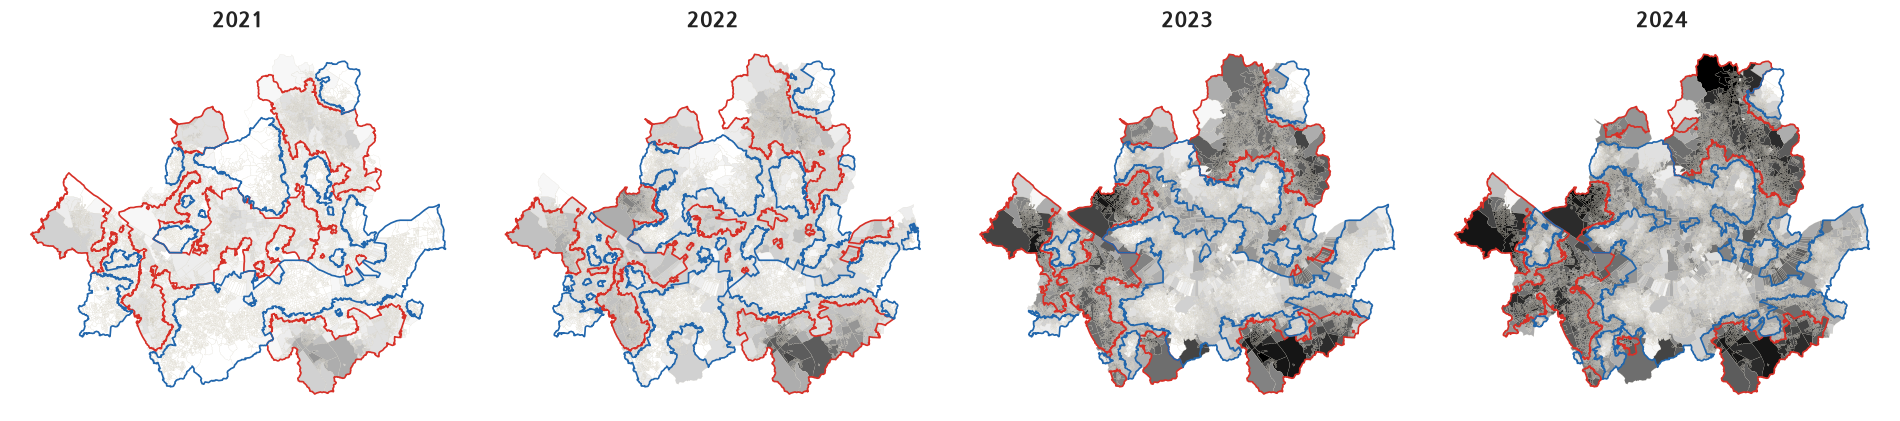

In [4]:
# 4. 4개년 통합 Natural Breaks 산출 및 1x4 지도 그리드 생성
print("=" * 80)
print("RUNNING: GAUSSIAN 2SFCA TEMPORAL GRID MAP GENERATION")
print("=" * 80)

# 1. 4개년 점수 통합 및 공통 구간 경계(Natural Breaks, k=15) 계산
pooled_scores = np.concatenate(list(scores_by_year.values()))
nb = mapclassify.NaturalBreaks(pooled_scores, k=K_CLASSES)
bins = nb.bins
norm = Normalize(vmin=0, vmax=K_CLASSES - 1)

print(f">> 4개년 통합 Natural Breaks(k={K_CLASSES}) 구간 상한값:")
print(np.round(bins, 4))

# 2. 1행 4열 Figure 구성
fig, axes = plt.subplots(1, len(YEARS), figsize=(20, 6.4), facecolor="white")
plt.subplots_adjust(top=0.84, bottom=0.14, left=0.03, right=0.97, wspace=0.04)

for c, year in enumerate(YEARS):
    ax = axes[c]
    g = gdf_seoul.copy()
    g["score"] = scores_by_year[year]
    
    # 공통 구간 경계 기반 인덱싱 (0 ~ K_CLASSES-1)
    g["cls"] = np.digitize(g["score"], bins[:-1], right=True)
    g["gray_color"] = [Greys(norm(v)) for v in g["cls"]]

    # 배경: 접근성 점수 그레이스케일 폴리곤 플롯
    g.plot(ax=ax, color=g["gray_color"], edgecolor=BORDER_COLOR, linewidth=0.08)

    # 군집 외곽선 오버레이 (디졸브 후 미세 위상 틈새 완화)
    sub_hs = df_hs_2sfca[df_hs_2sfca["year"] == year].set_index("oa_code")
    g["gi_class"] = g["TOT_REG_CD"].map(sub_hs["gi_class"])
    
    dissolved = g.dissolve(by="gi_class")
    dissolved["geometry"] = dissolved.geometry.buffer(1).buffer(-1)

    if "Hot Spot" in dissolved.index:
        dissolved.loc[["Hot Spot"]].boundary.plot(ax=ax, color=HOT_LINE, linewidth=1.2)
    if "Cold Spot" in dissolved.index:
        dissolved.loc[["Cold Spot"]].boundary.plot(ax=ax, color=COLD_LINE, linewidth=1.2)

    ax.set_axis_off()
    ax.set_title(f"{year}", fontsize=15, fontweight="bold", color=TEXT_COLOR, pad=8)

# 5. Shared Legend, Academic Header & High-Res Export
- 전체 메인 타이틀 및 분석 윈도우 메타데이터 캡션 배치
- 하단 통합 수평 범례 구성 및 300 DPI 포스터 규격 이미지(`poster_2sfca_weekday_grid_mw.png`) 저장

In [5]:
# 5. 메인 헤더, 범례 및 파일 저장

# 전체 메인 타이틀 및 서브타이틀
fig.suptitle(
    "Temporal Dynamics of EV Charging Accessibility: Gaussian 2SFCA (2021–2024)",
    fontsize=16, fontweight="bold", color=TEXT_COLOR, y=0.96
)
fig.text(
    0.5, 0.90,
    "Weekdays Daytime (11:00-13:00) | Background: Natural Breaks (k=15, 4-yr pooled) | Outlines: Gi* Clusters (KNN k=30, p < 0.05)",
    ha="center", fontsize=10.5, color=MUTED_COLOR
)

# 하단 수평 통합 범례 (중앙 배치)
legend_handles = [
    mpatches.Patch(facecolor=Greys(norm(0)), edgecolor=BORDER_COLOR, label="접근성 낮음 (Low)"),
    mpatches.Patch(facecolor=Greys(norm(K_CLASSES - 1)), edgecolor=BORDER_COLOR, label="접근성 높음 (High)"),
    Line2D([0], [0], color=HOT_LINE, linewidth=1.8, label="Hot Spot 경계 (p < 0.05)"),
    Line2D([0], [0], color=COLD_LINE, linewidth=1.8, label="Cold Spot 경계 (p < 0.05)"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.03)
)

# 고해상도(300 DPI) 이미지 내보내기 및 화면 출력
fig.savefig(OUT_FP, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n>> 포스터 Option A 전용 고해상도 시계열 지도 저장 완료: {OUT_FP}")


>> 포스터 Option A 전용 고해상도 시계열 지도 저장 완료: /mnt/cowork/EV/output/maps/poster_2sfca_weekday_grid_mw.png


# 6. Output Verification
- 생성된 300 DPI 고해상도 래스터 이미지 파일의 경로 및 용량(MB) 무결성 검증

In [6]:
# 6. 산출물 파일 상태 확인
if OUT_FP.exists():
    file_size_mb = OUT_FP.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_FP.name}")
    print(f"  절대 경로 : {OUT_FP.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 저장 완료 (학술 포스터 인쇄 규격 300 DPI 충족)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_FP}")

  파일명    : poster_2sfca_weekday_grid_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/poster_2sfca_weekday_grid_mw.png
  파일 크기 : 3.99 MB
  상태      : 정상 저장 완료 (학술 포스터 인쇄 규격 300 DPI 충족)
